## House Price Prediction Using Advanced Regression Techniques

#### Importing libraries and loading data

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


#### Checking the data

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
sample_submission.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


#### Checking the target column

In [7]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

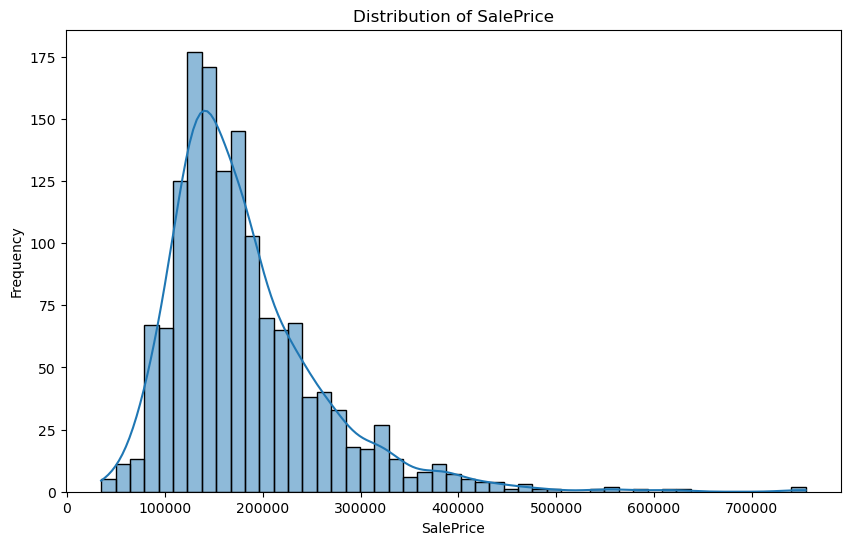

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

#### Separating features and target

In [9]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

test_ids = test["Id"]

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test shape:", test.shape)

X shape: (1460, 80)
y shape: (1460,)
Test shape: (1459, 80)


#### Combining train and test for preprocessing

In [11]:
combined = pd.concat([X, test], axis=0)

print("Combined shape:", combined.shape)

Combined shape: (2919, 80)


#### Droping Id

In [12]:
combined = combined.drop("Id", axis=1)

#### Handle missing values

In [13]:
numeric_cols = combined.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = combined.select_dtypes(include=["object"]).columns

print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 36
Categorical columns: 43


In [14]:
# Fill missing values for numerical values with median
combined[numeric_cols] = combined[numeric_cols].fillna(combined[numeric_cols].median())

In [15]:
# Fill missing values for categorical columns with mode
for col in categorical_cols:
    combined[col] = combined[col].fillna(combined[col].mode()[0])

In [16]:
# check missing values
combined.isnull().sum().sum()

0

#### Encoding categorical columns

In [17]:
combined_encoded = pd.get_dummies(combined, drop_first=True)

print("Encoded shape:", combined_encoded.shape)

Encoded shape: (2919, 244)


#### Spliting back into train and test

In [18]:
X_processed = combined_encoded.iloc[:len(train), :]
test_processed = combined_encoded.iloc[len(train):, :]

print("Processed training data:", X_processed.shape)
print("Processed test data:", test_processed.shape)

Processed training data: (1460, 244)
Processed test data: (1459, 244)


#### Train/validation split

In [19]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (1168, 244)
Validation set: (292, 244)
